# 04 Business Insights and Retention Strategy

## Project Context
This notebook turns the churn analysis into business recommendations for a Netflix-like streaming platform.

## Objectives
- Segment customers by engagement and value
- Estimate simple customer lifetime value (CLV) by plan and segment
- Summarize revenue patterns
- Test whether manually scored categorical variables add useful signal
- Translate findings into retention actions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## 1. Load the Cleaned Dataset

In [2]:
data_path = "../data/processed/netflix_churn_cleaned.csv"
df = pd.read_csv(data_path)

df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


## 2. Customer Segmentation

Customers are grouped using engagement and value-related features. The purpose is not to create a production segmentation system, but to identify practical retention groups.

In [3]:
segmentation_features = [
    "age",
    "watch_hours",
    "monthly_fee",
    "avg_watch_time_per_day",
    "number_of_profiles",
]

scaler = StandardScaler()
scaled_segments = scaler.fit_transform(df[segmentation_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["segment"] = kmeans.fit_predict(scaled_segments)

segment_summary = df.groupby("segment").agg(
    customers=("churned", "size"),
    churn_rate=("churned", "mean"),
    avg_watch_hours=("watch_hours", "mean"),
    avg_daily_watch_time=("avg_watch_time_per_day", "mean"),
    avg_monthly_fee=("monthly_fee", "mean"),
    avg_profiles=("number_of_profiles", "mean"),
).round(2)

segment_summary

,customers,churn_rate,avg_watch_hours,avg_daily_watch_time,avg_monthly_fee,avg_profiles
segment,,,,,,
0,1611,0.47,9.95,0.52,16.00,3.05
1,1583,0.47,11.01,0.54,16.06,3.02
2,1596,0.64,10.29,0.55,8.99,3.00
3,210,0.00,39.88,7.88,13.68,3.07


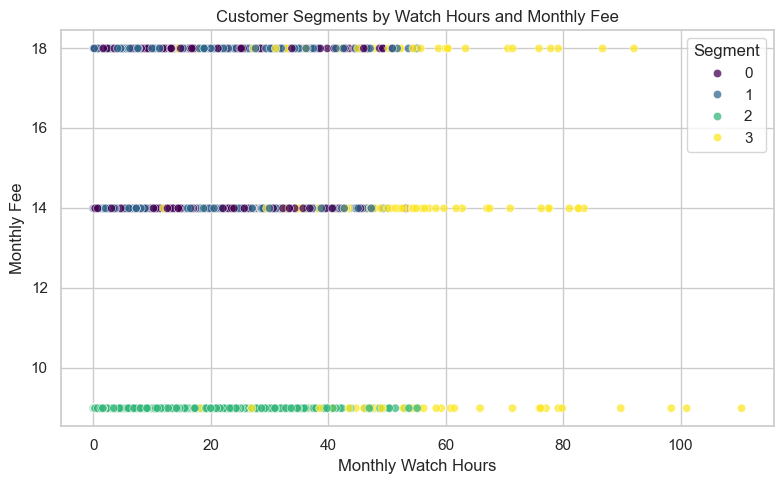

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="watch_hours",
    y="monthly_fee",
    hue="segment",
    palette="viridis",
    alpha=0.75,
)
plt.title("Customer Segments by Watch Hours and Monthly Fee")
plt.xlabel("Monthly Watch Hours")
plt.ylabel("Monthly Fee")
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

## 3. Customer Lifetime Value (CLV)

This project uses a simplified subscription CLV estimate:

`CLV = average monthly fee / churn rate`

This is not a full finance-grade CLV model, but it is useful for comparing customer groups in this dataset.

In [5]:
overall_arpu = df["monthly_fee"].mean()
overall_churn_rate = df["churned"].mean()
overall_clv = overall_arpu / overall_churn_rate

print(f"Average Revenue Per User (ARPU): ${overall_arpu:.2f}")
print(f"Overall churn rate: {overall_churn_rate:.2%}")
print(f"Simplified overall CLV: ${overall_clv:.2f}")

Average Revenue Per User (ARPU): $13.68
Overall churn rate: 50.30%
Simplified overall CLV: $27.20


In [6]:
clv_by_plan = df.groupby("subscription_type").agg(
    arpu=("monthly_fee", "mean"),
    churn_rate=("churned", "mean"),
    customers=("churned", "size"),
)
clv_by_plan["estimated_clv"] = clv_by_plan["arpu"] / clv_by_plan["churn_rate"]
clv_by_plan.round(2).sort_values("estimated_clv", ascending=False)

,arpu,churn_rate,customers,estimated_clv
subscription_type,,,,
Premium,17.99,0.44,1693,41.16
Standard,13.99,0.45,1646,30.79
Basic,8.99,0.62,1661,14.54


In [7]:
clv_by_segment = df.groupby("segment").agg(
    arpu=("monthly_fee", "mean"),
    churn_rate=("churned", "mean"),
    customers=("churned", "size"),
)
clv_by_segment["estimated_clv"] = clv_by_segment["arpu"] / clv_by_segment["churn_rate"]
clv_by_segment.round(2).sort_values("estimated_clv", ascending=False)

,arpu,churn_rate,customers,estimated_clv
segment,,,,
3,13.68,0.00,210,inf
1,16.06,0.47,1583,34.49
0,16.00,0.47,1611,34.32
2,8.99,0.64,1596,13.97


## 4. Revenue Analysis

In [8]:
total_revenue = df["monthly_fee"].sum()
revenue_by_region = df.groupby("region")["monthly_fee"].sum().sort_values(ascending=False)
revenue_by_plan = df.groupby("subscription_type")["monthly_fee"].sum().sort_values(ascending=False)

print(f"Total monthly revenue represented in dataset: ${total_revenue:,.2f}")
print("\nRevenue by region:")
print(revenue_by_region)
print("\nRevenue by subscription type:")
print(revenue_by_plan)

Total monthly revenue represented in dataset: $68,417.00

Revenue by region:
region
South America    11921.27
Europe           11865.33
North America    11607.49
Asia             11436.59
Africa           11001.97
Oceania          10584.35
Name: monthly_fee, dtype: float64

Revenue by subscription type:
subscription_type
Premium     30457.07
Standard    23027.54
Basic       14932.39
Name: monthly_fee, dtype: float64


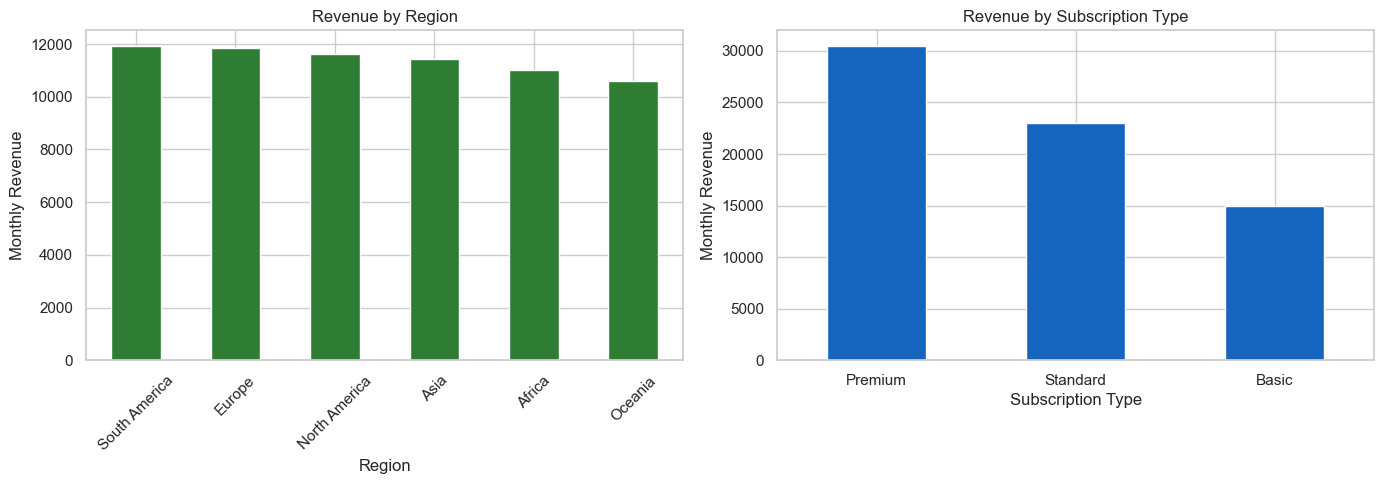

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

revenue_by_region.plot(kind="bar", ax=axes[0], color="#2E7D32")
axes[0].set_title("Revenue by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Monthly Revenue")
axes[0].tick_params(axis="x", rotation=45)

revenue_by_plan.plot(kind="bar", ax=axes[1], color="#1565C0")
axes[1].set_title("Revenue by Subscription Type")
axes[1].set_xlabel("Subscription Type")
axes[1].set_ylabel("Monthly Revenue")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 5. Categorical Scoring Experiment

The original project called this sentiment analysis. Because the dataset does not include review text or user comments, this is better described as a small categorical scoring experiment. The goal is to check whether hand-scored genre and payment categories show any visible churn pattern.

In [10]:
genre_score = {
    "Drama": 1,
    "Comedy": 1,
    "Action": 0,
    "Sci-Fi": 0,
    "Horror": -1,
}

payment_score = {
    "Credit Card": 1,
    "Debit Card": 1,
    "PayPal": 1,
    "Gift Card": -1,
    "Crypto": -1,
}

df["genre_score"] = df["favorite_genre"].map(genre_score)
df["payment_score"] = df["payment_method"].map(payment_score)
df["categorical_score"] = df[["genre_score", "payment_score"]].mean(axis=1)

score_summary = df.groupby("categorical_score").agg(
    customers=("churned", "size"),
    churn_rate=("churned", "mean"),
).round(3)

score_summary

,customers,churn_rate
categorical_score,,
-1.0,880,0.585
-0.5,565,0.556
0.0,944,0.557
0.5,852,0.458
1.0,1759,0.438


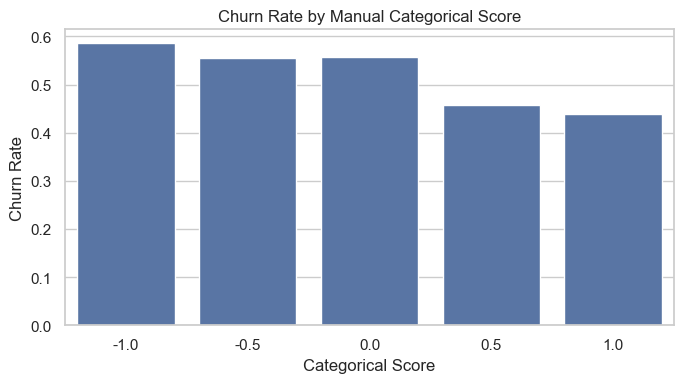

In [11]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="categorical_score", y="churned", errorbar=None)
plt.title("Churn Rate by Manual Categorical Score")
plt.xlabel("Categorical Score")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

## 6. Retention Recommendations

### Re-engage inactive users
Users with higher `last_login_days` are more likely to churn. Create automated outreach at 14, 30, and 45 inactive days with personalized content reminders.

### Increase engagement for low-watch users
Low `watch_hours` and `avg_watch_time_per_day` are strong churn signals. Build a low-engagement audience and test personalized recommendations or short-term incentives.

### Reduce churn among Basic plan users
Basic users show lower value and higher churn risk. Test upgrade trials, plan education, or targeted bundles, then measure retention lift.

### Protect high-value household accounts
Accounts with more profiles tend to be more stable and valuable. Avoid surprising policy changes for this group and consider loyalty-oriented retention actions.

### Monitor with model scores and A/B testing
Use churn scores to prioritize outreach, but validate every retention action with controlled experiments.

## 7. Final Conclusion

The main churn driver is engagement. Customers who watch less, spend less time per day, or have been inactive longer are more likely to cancel. Subscription tier and multi-profile usage add useful business context, but demographic variables are less important.

For a streaming platform, the practical strategy is to detect low-engagement behavior early, re-engage inactive users, and protect high-value customers before they churn.